# Mathematical Mapping of Emergent Digit Reading, Folding Math, and Hexadecimal Twin Structures
## Reproducibility Notebook

This notebook is a clean computational companion to **"Mathematical Mapping of Emergent Digit Reading, Folding Math, and Hexadecimal Twin Structures"**.

It reproduces the paper's core claims in a strict, testable way:

- the fixed four-byte arithmetic-residue encoding,
- the affine residue law,
- horizontal and vertical deltas,
- diagonal trajectories,
- parity conservation and modulo-4 collapse,
- non-commutative positional memory,
- hexadecimal twin structures,
- the "fold at 10",
- bounded reverse-branch enumeration,
- and an optional BBP spot-check as the prototype harmonic address resolver.

### Modeling note

To preserve the paper's exact linear lattice, this notebook uses the **fixed four-byte encoding**

$$
[\,0x30+a,\ 0x2B,\ 0x30+b,\ 0x3D\,]
$$

for integer coordinates \(a,b \in \{1,\dots,10\}\).

This is the affine byte-lattice model used by the delta proofs.  
It is **not** the same as variable-length literal decimal strings like `"10+10="`.

That distinction matters. The paper's 10x10 lattice claims are true in the fixed-byte model.

In [1]:
import math
import itertools
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Core encoding model

For each ordered pair \((a,b)\), define the four-byte object

$$
B(a,b) = [\,0x30+a,\ 0x2B,\ 0x30+b,\ 0x3D\,].
$$

Concatenate the bytes as a big-endian hexadecimal integer and extract the final two decimal digits:

$$
R(a,b) = \operatorname{int}\!\big(\texttt{hex}(B(a,b))\big)\bmod 100.
$$

The paper's affine law is

$$
R(a,b)\equiv 37 + 16(a-1) + 56(b-1) \pmod{100}.
$$

In [2]:
DOMAIN = range(1, 11)

def bytes_for_pair(a: int, b: int):
    return [0x30 + a, 0x2B, 0x30 + b, 0x3D]

def concat_hex_value(a: int, b: int) -> int:
    value = 0
    for byt in bytes_for_pair(a, b):
        value = (value << 8) | byt
    return value

def residue(a: int, b: int) -> int:
    return concat_hex_value(a, b) % 100

def residue_affine(a: int, b: int) -> int:
    return (37 + 16*(a-1) + 56*(b-1)) % 100

def residue_hex(a: int, b: int) -> str:
    return f"{residue(a,b):02X}"

def residue_bin(a: int, b: int) -> str:
    return f"{residue(a,b):08b}"

for a in DOMAIN:
    for b in DOMAIN:
        assert residue(a, b) == residue_affine(a, b)

print("Affine lattice law verified on the full 10x10 domain.")

Affine lattice law verified on the full 10x10 domain.


In [3]:
decimal_grid = pd.DataFrame(
    [[residue(a, b) for b in DOMAIN] for a in DOMAIN],
    index=[f"a={a}" for a in DOMAIN],
    columns=[f"b={b}" for b in DOMAIN],
)

hex_grid = pd.DataFrame(
    [[residue_hex(a, b) for b in DOMAIN] for a in DOMAIN],
    index=[f"a={a}" for a in DOMAIN],
    columns=[f"b={b}" for b in DOMAIN],
)

binary_grid = pd.DataFrame(
    [[residue_bin(a, b) for b in DOMAIN] for a in DOMAIN],
    index=[f"a={a}" for a in DOMAIN],
    columns=[f"b={b}" for b in DOMAIN],
)

decimal_grid.head()

,b=1,b=2,b=3,b=4,b=5,b=6,b=7,b=8,b=9,b=10
a=1,37,93,49,5,61,17,73,29,85,41
a=2,53,9,65,21,77,33,89,45,1,57
a=3,69,25,81,37,93,49,5,61,17,73
a=4,85,41,97,53,9,65,21,77,33,89
a=5,1,57,13,69,25,81,37,93,49,5


## 2. Decimal, hexadecimal, and binary residue grids

In [4]:
hex_grid.head()

,b=1,b=2,b=3,b=4,b=5,b=6,b=7,b=8,b=9,b=10
a=1,25,5D,31,05,3D,11,49,1D,55,29
a=2,35,09,41,15,4D,21,59,2D,01,39
a=3,45,19,51,25,5D,31,05,3D,11,49
a=4,55,29,61,35,09,41,15,4D,21,59
a=5,01,39,0D,45,19,51,25,5D,31,05


In [5]:
binary_grid.head()

,b=1,b=2,b=3,b=4,b=5,b=6,b=7,b=8,b=9,b=10
a=1,00100101,01011101,00110001,00000101,00111101,00010001,01001001,00011101,01010101,00101001
a=2,00110101,00001001,01000001,00010101,01001101,00100001,01011001,00101101,00000001,00111001
a=3,01000101,00011001,01010001,00100101,01011101,00110001,00000101,00111101,00010001,01001001
a=4,01010101,00101001,01100001,00110101,00001001,01000001,00010101,01001101,00100001,01011001
a=5,00000001,00111001,00001101,01000101,00011001,01010001,00100101,01011101,00110001,00000101


## 3. Horizontal and vertical deltas

Because the \(b\)-byte sits one full byte above the final `=` byte, incrementing \(b\) adds

$$
16^2 = 256 \equiv 56 \pmod{100}.
$$

Because the \(a\)-byte sits in the highest position, incrementing \(a\) adds

$$
16^6 = 16{,}777{,}216 \equiv 16 \pmod{100}.
$$

In [6]:
HORIZONTAL_DELTA = 56
VERTICAL_DELTA = 16

for a in DOMAIN:
    for b in range(1, 10):
        assert (residue(a, b+1) - residue(a, b)) % 100 == HORIZONTAL_DELTA

for a in range(1, 10):
    for b in DOMAIN:
        assert (residue(a+1, b) - residue(a, b)) % 100 == VERTICAL_DELTA

print(f"Horizontal delta verified: +{HORIZONTAL_DELTA} mod 100")
print(f"Vertical delta verified:   +{VERTICAL_DELTA} mod 100")

Horizontal delta verified: +56 mod 100
Vertical delta verified:   +16 mod 100


## 4. Diagonal trajectories

The main diagonal step \((a,b)\mapsto(a+1,b+1)\) adds

$$
16 + 56 = 72 \pmod{100}.
$$

The anti-diagonal step \((a,b)\mapsto(a+1,b-1)\) adds

$$
16 - 56 \equiv -40 \equiv 60 \pmod{100}.
$$

In [7]:
MAIN_DIAGONAL_DELTA = (VERTICAL_DELTA + HORIZONTAL_DELTA) % 100
ANTI_DIAGONAL_DELTA = (VERTICAL_DELTA - HORIZONTAL_DELTA) % 100

for a in range(1, 10):
    for b in range(1, 10):
        assert (residue(a+1, b+1) - residue(a, b)) % 100 == MAIN_DIAGONAL_DELTA

for a in range(1, 10):
    for b in range(2, 11):
        assert (residue(a+1, b-1) - residue(a, b)) % 100 == ANTI_DIAGONAL_DELTA

print(f"Main diagonal delta verified: +{MAIN_DIAGONAL_DELTA} mod 100")
print(f"Anti-diagonal delta verified: +{ANTI_DIAGONAL_DELTA} mod 100")

Main diagonal delta verified: +72 mod 100
Anti-diagonal delta verified: +60 mod 100


## 5. Parity conservation and modulo-4 collapse

The paper claims something stronger than "all residues are odd":

$$
R(a,b)\equiv 1 \pmod{4}.
$$

Since

$$
R(a,b)\equiv 37 + 16(a-1) + 56(b-1)\pmod{100},
$$

and both \(16\) and \(56\) are multiples of \(4\), we get

$$
R(a,b)\equiv 37 \equiv 1 \pmod{4}.
$$

So only the 25 residues congruent to \(1 \pmod{4}\) can appear.

In [8]:
reachable_residues = sorted({residue(a, b) for a in DOMAIN for b in DOMAIN})

assert all(r % 2 == 1 for r in reachable_residues)
assert all(r % 4 == 1 for r in reachable_residues)
assert len(reachable_residues) == 25

reachable_residues

[1,
 5,
 9,
 13,
 17,
 21,
 25,
 29,
 33,
 37,
 41,
 45,
 49,
 53,
 57,
 61,
 65,
 69,
 73,
 77,
 81,
 85,
 89,
 93,
 97]

## 6. Positional memory and swap torque

Swapping operands does **not** preserve residue. The paper's swap law is

$$
\Delta_{\mathrm{swap}}(a,b)
=
R(a,b)-R(b,a)
\equiv 40(b-a)\pmod{100}.
$$

This is the exact non-commutative torque induced by unequal byte weights.

In [9]:
def swap_delta(a: int, b: int) -> int:
    return (residue(a, b) - residue(b, a)) % 100

for a in DOMAIN:
    for b in DOMAIN:
        assert swap_delta(a, b) == (40*(b-a)) % 100

examples = pd.DataFrame(
    [
        {"pair": "(1,2)", "R(a,b)": residue(1,2), "R(b,a)": residue(2,1), "Δ_swap": swap_delta(1,2)},
        {"pair": "(1,3)", "R(a,b)": residue(1,3), "R(b,a)": residue(3,1), "Δ_swap": swap_delta(1,3)},
        {"pair": "(1,6)", "R(a,b)": residue(1,6), "R(b,a)": residue(6,1), "Δ_swap": swap_delta(1,6)},
        {"pair": "(2,7)", "R(a,b)": residue(2,7), "R(b,a)": residue(7,2), "Δ_swap": swap_delta(2,7)},
    ]
)
examples

,pair,"R(a,b)","R(b,a)",Δ_swap
0,"(1,2)",93,53,40
1,"(1,3)",49,69,80
2,"(1,6)",17,17,0
3,"(2,7)",89,89,0


## 7. Hexadecimal twin structures

A twin nibble occurs when the high nibble equals the low nibble:

$$
R(a,b) = 0xNN
$$

for some hex digit \(N\). The paper highlights \(0x11\) and \(0x55\) as the main attractor twins in the 10x10 lattice.

In [10]:
def twin_nibble_coords():
    out = defaultdict(list)
    for a in DOMAIN:
        for b in DOMAIN:
            r = residue(a, b)
            hi, lo = divmod(r, 16)
            if hi == lo:
                out[f"0x{hi:X}{lo:X}"].append((a, b))
    return dict(out)

twins = twin_nibble_coords()
twins

{'0x11': [(1, 6), (3, 9), (6, 1), (8, 4), (10, 7)],
 '0x55': [(1, 9), (4, 1), (6, 4), (8, 7), (10, 10)]}

In [11]:
paper_twin_11 = [(1,6), (3,9), (6,1), (8,4), (10,7)]
paper_twin_55 = [(1,9), (4,1), (6,4), (8,7), (10,10)]

assert twins["0x11"] == paper_twin_11
assert twins["0x55"] == paper_twin_55

pd.DataFrame(
    [
        {"hex_twin": "0x11", "decimal": 17, "binary": f"{17:08b}", "coords": paper_twin_11},
        {"hex_twin": "0x55", "decimal": 85, "binary": f"{85:08b}", "coords": paper_twin_55},
    ]
)

,hex_twin,decimal,binary,coords
0,0x11,17,00010001,"[(1, 6), (3, 9), (6, 1), (8, 4), (10, 7)]"
1,0x55,85,01010101,"[(1, 9), (4, 1), (6, 4), (8, 7), (10, 10)]"


## 8. Diophantine localization of the 0x55 twin

Set the affine law equal to \(85\):

$$
37 + 16(a-1) + 56(b-1) \equiv 85 \pmod{100}.
$$

This simplifies to

$$
16a + 56b - 35 \equiv 85 \pmod{100},
$$

hence

$$
16a + 56b \equiv 120 \equiv 20 \pmod{100}.
$$

Dividing by \(4\) gives the paper's compact congruence:

$$
4a + 14b \equiv 5 \pmod{25}.
$$

In [12]:
def solve_residue_by_congruence(target: int, domain=DOMAIN):
    if target % 4 != 1:
        return []
    sols = []
    rhs = ((target + 35) // 4) % 25
    for a in domain:
        for b in domain:
            if (4*a + 14*b) % 25 == rhs:
                if residue(a, b) == target:
                    sols.append((a, b))
    return sols

assert solve_residue_by_congruence(85) == paper_twin_55
assert solve_residue_by_congruence(17) == paper_twin_11

solve_residue_by_congruence(85)

[(1, 9), (4, 1), (6, 4), (8, 7), (10, 10)]

## 9. The fold at 10

For the anti-diagonal \(a+b=10\) inside the 1–9 subdomain, the paper claims every residue ends in the digit \(5\).

We verify that directly.

In [13]:
sum10_pairs = [(a, 10-a) for a in range(1, 10)]
sum10_table = pd.DataFrame(
    [{"pair": pair, "residue": residue(*pair), "hex": residue_hex(*pair), "binary": residue_bin(*pair)}
     for pair in sum10_pairs]
)
assert all(row % 10 == 5 for row in sum10_table["residue"])

sum10_table

,pair,residue,hex,binary
0,"(1, 9)",85,55,01010101
1,"(2, 8)",45,2D,00101101
2,"(3, 7)",5,05,00000101
3,"(4, 6)",65,41,01000001
4,"(5, 5)",25,19,00011001
5,"(6, 4)",85,55,01010101
6,"(7, 3)",45,2D,00101101
7,"(8, 2)",5,05,00000101
8,"(9, 1)",65,41,01000001


The anti-diagonal step size is constant:

$$
R(a+1,\,b-1)-R(a,b)\equiv 60\pmod{100},
$$

so starting from \((1,9)\) the sequence remains trapped in the terminal-5 class.

In [14]:
anti_diag_residues = [residue(a, 10-a) for a in range(1, 10)]
anti_diag_deltas = [ (anti_diag_residues[i+1] - anti_diag_residues[i]) % 100 for i in range(len(anti_diag_residues)-1) ]
anti_diag_residues, anti_diag_deltas

([85, 45, 5, 65, 25, 85, 45, 5, 65], [60, 60, 60, 60, 60, 60, 60, 60])

## 10. Reverse branching / bounded unfolding

Because the lattice is surjective onto a 25-element residue class, reverse lookup is naturally multi-valued.

This cell enumerates all coordinates in the bounded 10x10 lattice that resolve to a chosen residue.

In [15]:
def reverse_branches(target: int, domain=DOMAIN):
    return [(a,b) for a in domain for b in domain if residue(a,b) == target]

for target in [17, 37, 45, 85, 93]:
    print(f"{target:02d} -> {reverse_branches(target)}")

17 -> [(1, 6), (3, 9), (6, 1), (8, 4), (10, 7)]
37 -> [(1, 1), (3, 4), (5, 7), (7, 10), (10, 2)]
45 -> [(2, 8), (7, 3), (9, 6)]
85 -> [(1, 9), (4, 1), (6, 4), (8, 7), (10, 10)]
93 -> [(1, 2), (3, 5), (5, 8), (10, 3)]


## 11. Visualizations

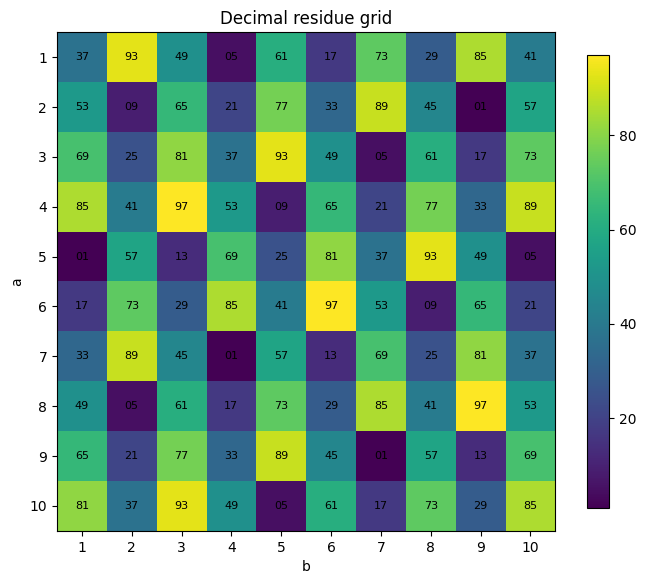

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(decimal_grid.values)
ax.set_title("Decimal residue grid")
ax.set_xticks(range(10), labels=list(DOMAIN))
ax.set_yticks(range(10), labels=list(DOMAIN))
ax.set_xlabel("b")
ax.set_ylabel("a")

for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{decimal_grid.values[i,j]:02d}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

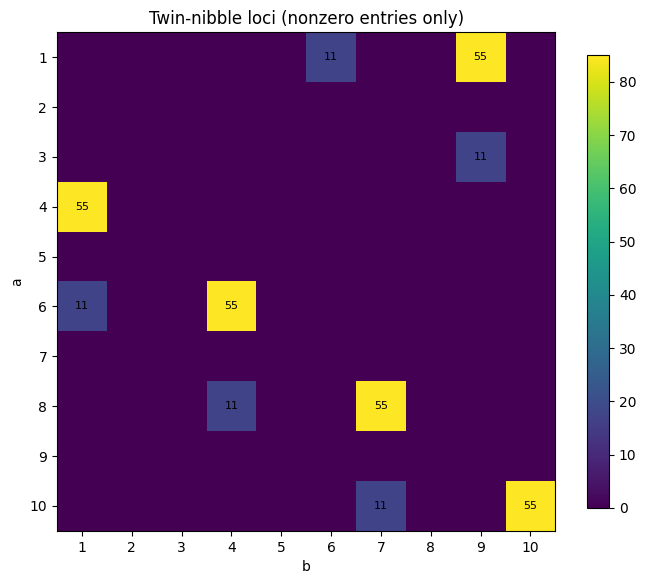

In [17]:
twin_mask = np.zeros((10, 10), dtype=int)
for a in DOMAIN:
    for b in DOMAIN:
        r = residue(a, b)
        hi, lo = divmod(r, 16)
        if hi == lo:
            twin_mask[a-1, b-1] = r

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(twin_mask)
ax.set_title("Twin-nibble loci (nonzero entries only)")
ax.set_xticks(range(10), labels=list(DOMAIN))
ax.set_yticks(range(10), labels=list(DOMAIN))
ax.set_xlabel("b")
ax.set_ylabel("a")

for i in range(10):
    for j in range(10):
        val = twin_mask[i, j]
        label = f"{val:02X}" if val else ""
        ax.text(j, i, label, ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

## 12. Optional appendix: BBP spot-check

The paper frames BBP as the prototype harmonic address resolver.  
This appendix gives a minimal hex-digit spot-check for \(\pi\), included only as a computational precursor.

In [18]:
from mpmath import mp

mp.dps = 200

def pi_hex_digits(n=16):
    x = mp.pi
    digits = []
    frac = x - int(x)
    for _ in range(n):
        frac *= 16
        d = int(frac)
        digits.append("0123456789ABCDEF"[d])
        frac -= d
    return "".join(digits)

print("First 16 hex digits of π after the point:")
print(pi_hex_digits(16))

First 16 hex digits of π after the point:
243F6A8885A308D3


## 13. Theorem checklist

In [19]:
checks = {
    "Affine lattice law": all(residue(a,b) == residue_affine(a,b) for a in DOMAIN for b in DOMAIN),
    "Horizontal delta = 56": all((residue(a,b+1)-residue(a,b)) % 100 == 56 for a in DOMAIN for b in range(1,10)),
    "Vertical delta = 16": all((residue(a+1,b)-residue(a,b)) % 100 == 16 for a in range(1,10) for b in DOMAIN),
    "Modulo-4 collapse": all(residue(a,b) % 4 == 1 for a in DOMAIN for b in DOMAIN),
    "Swap torque law": all(swap_delta(a,b) == (40*(b-a)) % 100 for a in DOMAIN for b in DOMAIN),
    "0x11 twin coordinates": twins["0x11"] == paper_twin_11,
    "0x55 twin coordinates": twins["0x55"] == paper_twin_55,
    "Fold-at-10 ends in 5": all(residue(a,10-a) % 10 == 5 for a in range(1,10)),
}

pd.DataFrame([{"claim": k, "verified": v} for k,v in checks.items()])

,claim,verified
0,Affine lattice law,True
1,Horizontal delta = 56,True
2,Vertical delta = 16,True
3,Modulo-4 collapse,True
4,Swap torque law,True
5,0x11 twin coordinates,True
6,0x55 twin coordinates,True
7,Fold-at-10 ends in 5,True
